In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the Airbnb listings dataset from a CSV file
airbnb = pd.read_csv("dataset/listings.csv")

airbnb

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
0,1.318800e+04,Riley Park,Entire home/apt,4,1.0,0.0,2.0,14
1,1.335800e+04,Downtown,Entire home/apt,2,1.0,1.0,1.0,20
2,1.349000e+04,Kensington-Cedar Cottage,Entire home/apt,2,1.0,1.0,1.0,35
3,1.426700e+04,Kensington-Cedar Cottage,Entire home/apt,4,1.0,1.0,2.0,35
4,1.625400e+04,Hastings-Sunrise,Entire home/apt,4,1.0,2.0,3.0,36
...,...,...,...,...,...,...,...,...
4981,9.970000e+17,Downtown,Entire home/apt,4,1.0,1.0,2.0,3000
4982,9.970000e+17,South Cambie,Entire home/apt,4,NaN,2.0,NaN,5714
4983,9.970000e+17,South Cambie,Private room,2,1.0,1.0,0.0,8495
4984,9.970000e+17,Downtown,Entire home/apt,4,NaN,2.0,NaN,9600


In [4]:
# Calculate and return the average price from the "price" column in the Airbnb dataset
airbnb["price"].mean()

np.float64(249.16526273565984)

In [14]:
# Set the random seed to 100 for reproducibility
#np.random.seed(100)

# Randomly select a sample of 40 rows from the Airbnb dataset and calculate the average price from the "price" column
airbnb.sample(n=40)["price"].mean()

np.float64(226.75)

In [15]:
# Initialize an empty list to store the samples
sample_list = []

# Take 20,000 samples, each with 40 listings, and label them by replicate number
for i in range(20_000):
    sample = airbnb.sample(40)           # Randomly sample 40 listings
    sample = sample.assign(replicate=i)  # Add a column to track the replicate number
    sample_list.append(sample)           # Append the sample to the list

# Combine all samples into one large DataFrame
samples = pd.concat(sample_list)

# Display the combined DataFrame
# samples

In [16]:
samples

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
268,6.166558e+06,Fairview,Entire home/apt,6,NaN,2.0,NaN,70,0
2386,4.946913e+07,Sunset,Entire home/apt,2,1.0,0.0,1.0,180,0
2957,6.130000e+17,Mount Pleasant,Entire home/apt,2,1.0,1.0,1.0,219,0
187,3.812348e+06,Riley Park,Private room,2,1.0,1.0,1.0,64,0
4336,9.010000e+17,Mount Pleasant,Entire home/apt,2,1.0,1.0,1.0,390,0
...,...,...,...,...,...,...,...,...,...
35,4.613700e+05,Killarney,Private room,2,NaN,1.0,NaN,45,19999
3077,6.450000e+17,Marpole,Entire home/apt,4,1.0,2.0,2.0,227,19999
1871,3.948778e+07,Renfrew-Collingwood,Entire home/apt,5,NaN,2.0,NaN,152,19999
3171,6.670000e+17,Downtown,Entire home/apt,6,NaN,2.0,NaN,236,19999


In [18]:
sample_estimates = (
     samples
    .groupby("replicate")
    ["price"]
    .mean()
    .reset_index(name="sample_mean")
)

sample_estimates

,replicate,sample_mean
0,0,237.300
1,1,242.500
2,2,303.525
3,3,216.775
4,4,200.300
...,...,...
19995,19995,261.550
19996,19996,190.725
19997,19997,251.575
19998,19998,186.150


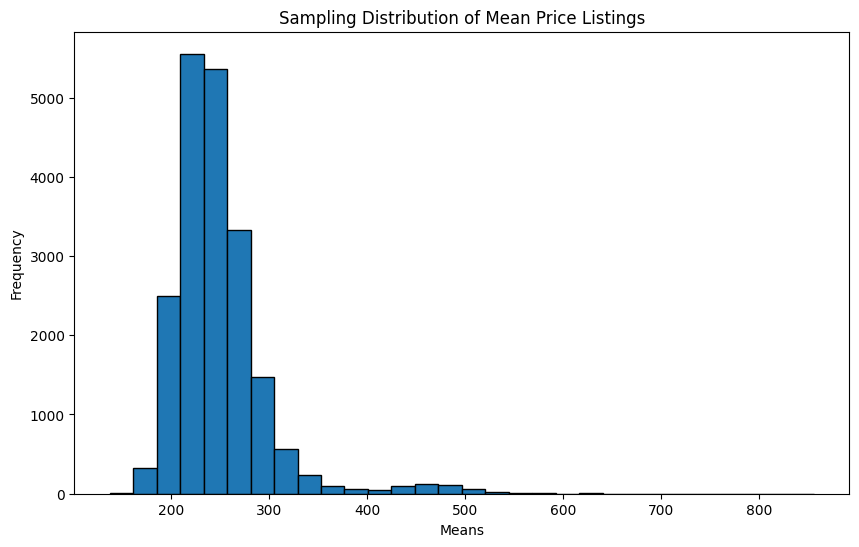

In [19]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(sample_estimates['sample_mean'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Sampling Distribution of Mean Price Listings')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [20]:
sample_estimates["sample_mean"].mean()

np.float64(248.728125)

In [21]:
# Bootstrap Concepts
np.random.seed(1234)
one_sample = airbnb.sample(n=40)
one_sample

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
2912,5.970000e+17,Riley Park,Entire home/apt,9,3.0,4.0,5.0,214
787,1.986261e+07,Mount Pleasant,Entire home/apt,9,2.0,3.0,3.0,109
2696,5.333958e+07,Arbutus Ridge,Entire home/apt,3,1.0,1.0,0.0,200
3017,6.310000e+17,West End,Entire home/apt,2,1.0,1.0,0.0,223
1226,2.745958e+07,Downtown,Entire home/apt,1,NaN,1.0,NaN,126
2620,5.255417e+07,Downtown Eastside,Entire home/apt,4,1.0,1.0,2.0,198
4883,9.790000e+17,Downtown Eastside,Entire home/apt,7,2.0,3.0,4.0,834
608,1.554257e+07,Kitsilano,Entire home/apt,5,1.0,2.0,3.0,99
1400,3.124019e+07,Arbutus Ridge,Private room,2,1.0,1.0,2.0,133
149,3.100878e+06,Downtown,Entire home/apt,2,1.0,1.0,0.0,60


In [22]:
one_sample["price"].mean()

np.float64(219.85)

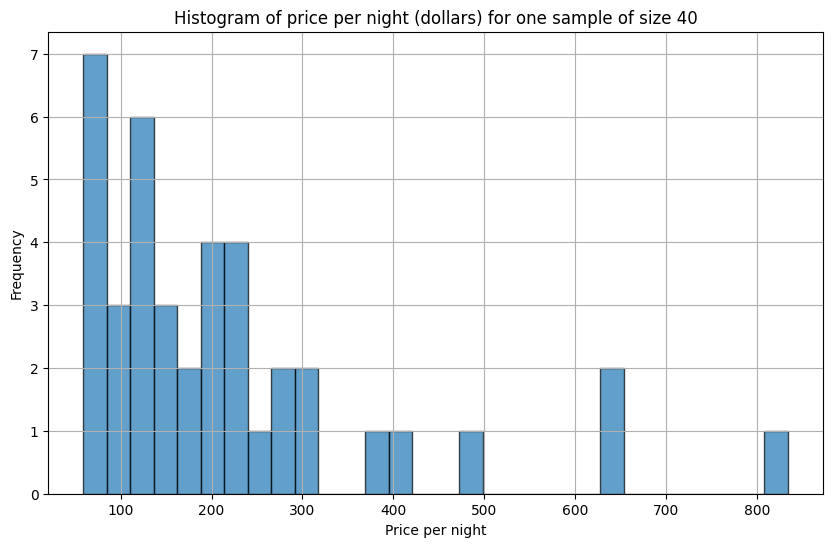

In [23]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(one_sample['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [24]:
one_sample["price"].mean()

np.float64(219.85)

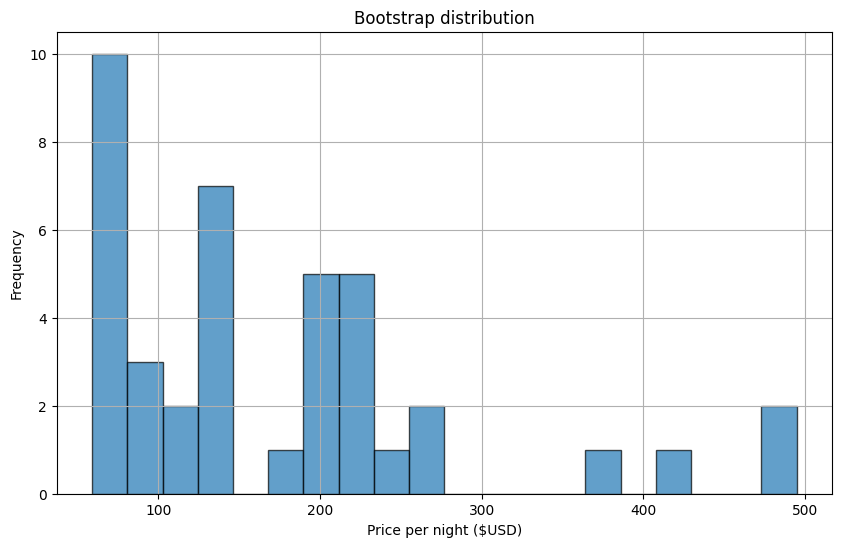

In [25]:
# Create a bootstrap sample from one_sample by sampling 100% of the rows (frac=1) with replacement.
boot1 = one_sample.sample(frac=1, replace=True)
# boot1 is the resulting bootstrap sample, where some rows may appear multiple times, and others may not appear at all.

# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot1['price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Bootstrap distribution')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [27]:
# Initialize an empty list to store the bootstrap samples
bootstrap_samples = []

for i in range(20000):
    sample = one_sample.sample(frac=1, replace=True)  # Sample with replacement
    sample = sample.assign(replicate=i)  # Add replicate number
    bootstrap_samples.append(sample)  # Store the sample

# Combine all bootstrap samples into one DataFrame
boot20000 = pd.concat(bootstrap_samples)

# Display the combined DataFrame
boot20000

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
1226,2.745958e+07,Downtown,Entire home/apt,1,NaN,1.0,NaN,126,0
2692,5.331242e+07,Strathcona,Entire home/apt,4,1.0,2.0,3.0,200,0
142,2.988185e+06,West End,Entire home/apt,4,NaN,2.0,NaN,59,0
3851,8.160000e+17,Hastings-Sunrise,Entire home/apt,4,1.0,2.0,2.0,300,0
4883,9.790000e+17,Downtown Eastside,Entire home/apt,7,2.0,3.0,4.0,834,0
...,...,...,...,...,...,...,...,...,...
1465,3.287258e+07,Kitsilano,Entire home/apt,4,2.0,2.0,2.0,136,19999
1619,3.519493e+07,West End,Entire home/apt,3,1.0,1.0,2.0,143,19999
3599,7.590000e+17,Kensington-Cedar Cottage,Entire home/apt,8,NaN,3.0,NaN,273,19999
4255,8.910000e+17,Downtown Eastside,Entire home/apt,4,1.0,0.0,0.0,372,19999


In [29]:
# Calculate the mean price for each bootstrap sample (replicate)
boot_means = boot20000.groupby('replicate')['price'].mean().reset_index(name='mean_price')
boot_means

,replicate,mean_price
0,0,221.500
1,1,217.450
2,2,232.525
3,3,239.075
4,4,255.750
...,...,...
19995,19995,237.275
19996,19996,209.400
19997,19997,216.400
19998,19998,195.425


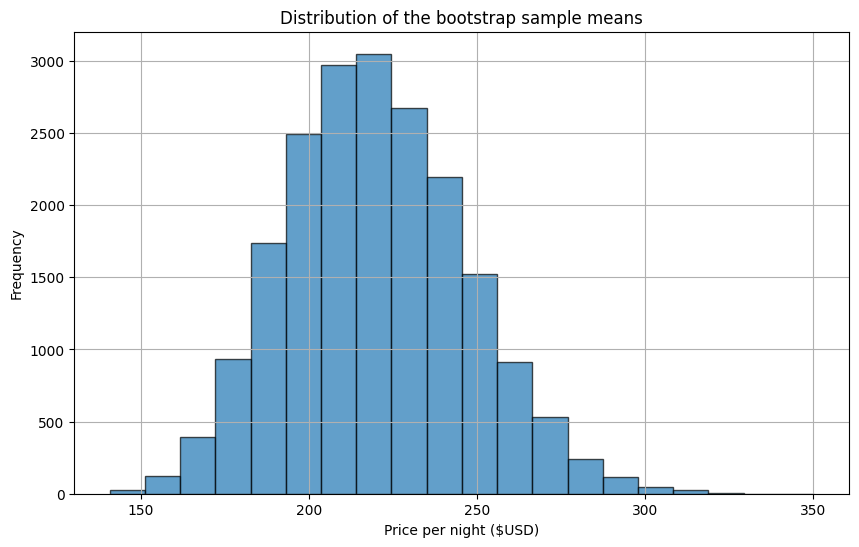

In [32]:
# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Distribution of the bootstrap sample means')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [31]:
boot_means["mean_price"].mean()

np.float64(219.93506499999998)

In [33]:
# Calculate the 95% confidence interval bounds (2.5th and 97.5th percentiles) for the mean price
ci_bounds = boot_means["mean_price"].quantile([0.025, 0.975])
ci_bounds

0.025    171.449375
0.975    275.675625
Name: mean_price, dtype: float64